# LAB 2: GRAY LEVEL TRANSFORMATION using function helper

Baseline Grayscale environment initialized successfully!


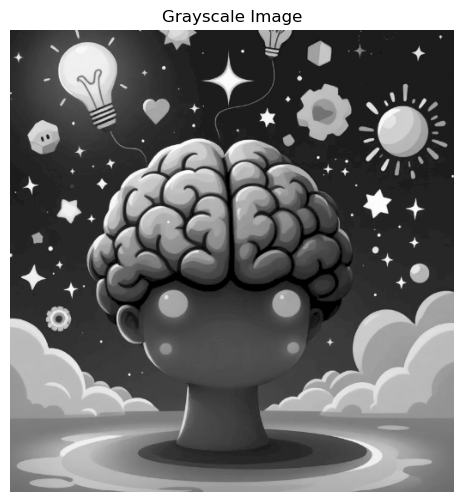

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Function to display images using matplotlib
def display (title, img, cmap = 'gray'):
  plt.figure(figsize = (6,6))
  plt.imshow(img, cmap = cmap)
  plt.title(title)
  plt.axis('off')
  plt.show()

# Load the baseline image in Grayscale mode directly
image_path = "IPPR_IMG.jpg"
gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray_img is None:
    print(f"Error: Could not load image from '{image_path}'. Check your file path!")
else:
    print("Baseline Grayscale environment initialized successfully!")

    # Show grayscale image
    display("Grayscale Image",gray_img)

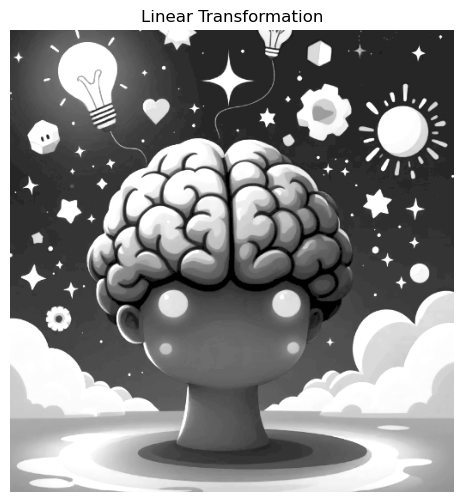

In [3]:
# Point Operation
def linear_transform(img, a = 1.2, b = 30):
      return cv2.convertScaleAbs(img, alpha = a, beta = b)
linear_img = linear_transform(gray_img)
display("Linear Transformation",linear_img)

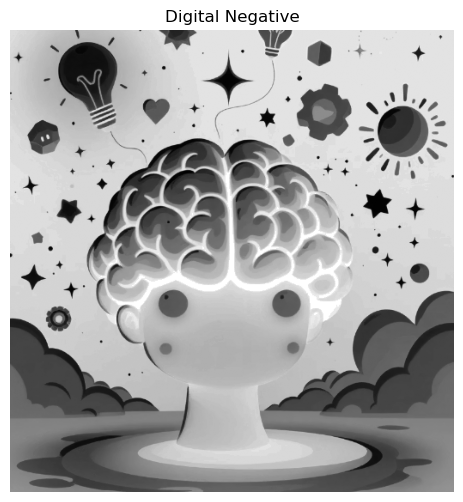

In [4]:
# Digital Negative
# s = L-1 - r
def negative(gray_img):
  return 255 - gray_img
neg_img = negative(gray_img)
display("Digital Negative",neg_img)

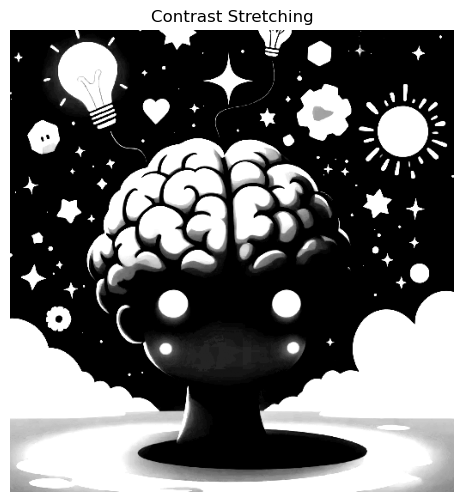

In [6]:
# Contrast Stretching: Piecewise Linear Transformation
def contrast_stretching(img, r1, s1, r2, s2):
    def pixel_val(p):
        if p < r1:
            return (s1/r1)*p
        elif p < r2:
            return ((s2-s1)/(r2-r1))*(p-r1)+s1
        else:
            return ((255-s2)/(255-r2))*(p-r2)+s2
    return np.array([pixel_val(p) for p in img.flatten()],dtype = 'uint8').reshape(img.shape)

contrast_img = contrast_stretching(gray_img, 70, 0, 140, 255)
display("Contrast Stretching",contrast_img)

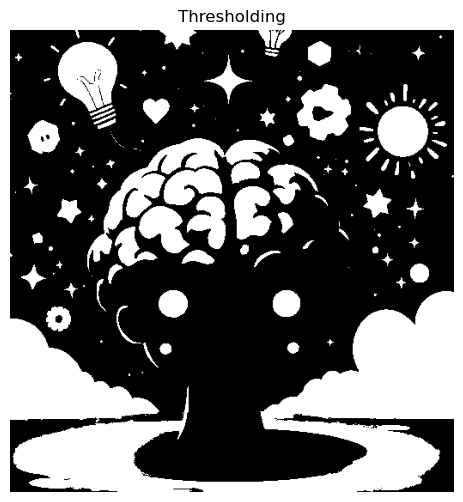

In [7]:
# Thresholding
def threshold(img, thresh_val=127):
      return cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY)[1]
thresh_img = threshold(gray_img)
display("Thresholding",thresh_img)

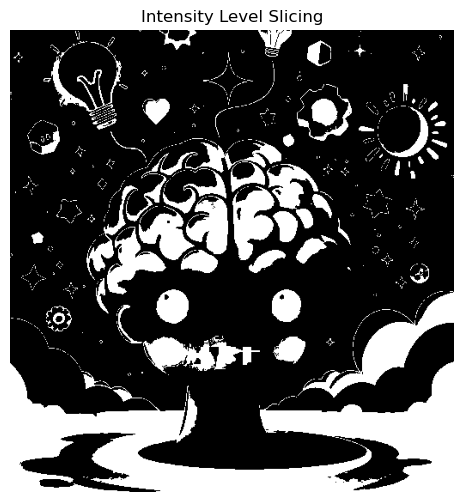

In [8]:
# Intensity Level Slicing

def intensity_slicing(gray, A, B, high=255, low=0):
      sliced = np.where((gray >= A) & (gray <= B), high, low)
      return sliced.astype(np.uint8)
sliced_img = intensity_slicing(gray_img, 80, 180)
display("Intensity Level Slicing",sliced_img)